# Recursive forecasting

this file contains the code to test recursive forecasting using a similar architecture which does not contain KAN layers.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import load_model

# ── CONFIG ────────────────────────────────
HIST_LEN = 36
HORIZON = 288
np.random.seed(23)

# ── LOAD DATA ─────────────────────────────
df_weather = pd.read_csv("../data/clean/valais_clean.csv")
df_weather["time"] = pd.to_datetime(df_weather["time"], format="%Y%m%d%H%M")
df_stations = pd.read_csv("../data/clean/valais_stations.csv")
df = df_weather.merge(df_stations[["station", "east", "north", "altitude"]], on="station", how="left")

# ── FEATURES ──────────────────────────────
selected_features = ['precip', 'temperature', 'East', 'North', 'pressure', 'moisture']
metadata_features = ['east', 'north', 'altitude']
all_features = selected_features + metadata_features

df_features = df[["time", "station"] + all_features].copy()
df_pivot = df_features.pivot(index="time", columns="station", values=all_features)
df_pivot.columns = [f"{feat}_{station}" for feat, station in df_pivot.columns]
df_pivot = df_pivot.sort_index().dropna()

# ── SPLIT AND SCALE ───────────────────────
split1 = int(0.6 * len(df_pivot))
split2 = int(0.8 * len(df_pivot))
df_train = df_pivot.iloc[:split1]
df_test  = df_pivot.iloc[split2:]

scaler = StandardScaler()
scaler.fit(df_train)
test_scaled = pd.DataFrame(scaler.transform(df_test), columns=df_test.columns, index=df_test.index)

# ── COLUMN SETUP ──────────────────────────
precip_cols = [col for col in df_test.columns if col.startswith("precip_")]
stations = [col.split('_')[1] for col in precip_cols]
true_precip = df_test[precip_cols].values

test_scaled_class = test_scaled  # full input for classifier
test_scaled_reg = test_scaled

# ── STATION METADATA (for regressor) ──────
station_meta = df_stations.set_index("station").loc[stations][['east', 'north', 'altitude']].values

## MLP Table

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tqdm import tqdm

# ── LOAD MODELS ───────────────────────────
regressor = load_model('../model_testing/regressor_mlp.keras')
classifier = load_model('../model_testing/classifier_mlp.keras')

# ── SELECT WINDOWS ────────────────────────
N = 10
indices = np.random.choice(len(test_scaled_class) - HIST_LEN - HORIZON, size=N, replace=False)
results = {h: {"mae": [], "rmse": []} for h in range(1, HORIZON + 1)}

# ── FORECAST LOOP ─────────────────────────
for idx in tqdm(indices, desc='processing indices'):
    x_class = test_scaled_class.iloc[idx:idx+HIST_LEN].values[np.newaxis, :, :]
    x_reg = test_scaled_reg.iloc[idx:idx+HIST_LEN].values[np.newaxis, :, :]
    y_true_seq = true_precip[idx + HIST_LEN + 1 : idx + HIST_LEN + 1 + HORIZON]

    forecast_seq = []

    for h in range(HORIZON):
        rain_probs = classifier.predict(x_class, verbose=0)[0]
        rain_mask = rain_probs > 0.8

        forecast_row = []
        for j in range(len(stations)):
            if rain_mask[j]:
                station_input = station_meta[j][np.newaxis, :]  # shape (1, 3)
                log_y_hat = regressor.predict(x_reg, verbose=0)[0][0]
                y_hat = np.expm1(log_y_hat)
            else:
                y_hat = 0.0
            forecast_row.append(y_hat)

        forecast_seq.append(forecast_row)

        # Prepare next input (recursive): update precip only
        if h < HORIZON - 1:
            next_input_class = x_class[0, 1:, :].copy()
            next_input_reg = x_reg[0, 1:, :].copy()

            last_class = x_class[0, -1, :].copy()
            last_reg = x_reg[0, -1, :].copy()

            for j, station in enumerate(stations):
                col_class = f"precip_{station}"
                col_reg = f"precip_{station}"
                idx_class = test_scaled_class.columns.get_loc(col_class)
                idx_reg = test_scaled_reg.columns.get_loc(col_reg)
                last_class[idx_class] = forecast_row[j]
                last_reg[idx_reg] = forecast_row[j]

            x_class = np.concatenate([next_input_class, [last_class]])[np.newaxis, :, :]
            x_reg = np.concatenate([next_input_reg, [last_reg]])[np.newaxis, :, :]

    forecast_seq = np.array(forecast_seq)  # (HORIZON, num_stations)

    for h in range(1, HORIZON + 1):
        y_t = y_true_seq[h-1]
        y_p = forecast_seq[h-1]
        results[h]["mae"].append(mean_absolute_error(y_t, y_p))
        results[h]["rmse"].append(np.sqrt(mean_squared_error(y_t, y_p)))

# ── BUILD SUMMARY TABLE ───────────────────
table_mlp = pd.DataFrame({
    "Horizon": range(1, HORIZON + 1),
    "MAE": [np.mean(results[h]["mae"]) for h in range(1, HORIZON + 1)],
    "RMSE": [np.mean(results[h]["rmse"]) for h in range(1, HORIZON + 1)]
})

processing indices: 100%|██████████| 10/10 [08:09<00:00, 48.97s/it]


## KAN Table

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tqdm import tqdm
from keras_efficient_kan import KANLinear
# ── LOAD MODELS ───────────────────────────
classifier = load_model('../model_testing/forecast_binary_1.keras')
regressor = load_model('../model_testing/final_one_step_fcst_wide.keras')

# ── SELECT WINDOWS ────────────────────────
N = 10
indices = np.random.choice(len(test_scaled_class) - HIST_LEN - HORIZON, size=N, replace=False)
results = {h: {"mae": [], "rmse": []} for h in range(1, HORIZON + 1)}

# ── FORECAST LOOP ─────────────────────────
for idx in tqdm(indices, desc='processing indices'):
    x_class = test_scaled_class.iloc[idx:idx+HIST_LEN].values[np.newaxis, :, :]
    x_reg = test_scaled_reg.iloc[idx:idx+HIST_LEN].values[np.newaxis, :, :]
    y_true_seq = true_precip[idx + HIST_LEN + 1 : idx + HIST_LEN + 1 + HORIZON]

    forecast_seq = []

    for h in range(HORIZON):
        rain_probs = classifier.predict(x_class, verbose=0)[0]
        rain_mask = rain_probs > 0.8

        forecast_row = []
        for j in range(len(stations)):
            if rain_mask[j]:
                station_input = station_meta[j][np.newaxis, :]  # shape (1, 3)
                log_y_hat = regressor.predict(x_reg, verbose=0)[0][0]
                y_hat = np.expm1(log_y_hat)
            else:
                y_hat = 0.0
            forecast_row.append(y_hat)

        forecast_seq.append(forecast_row)

        # Prepare next input (recursive): update precip only
        if h < HORIZON - 1:
            next_input_class = x_class[0, 1:, :].copy()
            next_input_reg = x_reg[0, 1:, :].copy()

            last_class = x_class[0, -1, :].copy()
            last_reg = x_reg[0, -1, :].copy()

            for j, station in enumerate(stations):
                col_class = f"precip_{station}"
                col_reg = f"precip_{station}"
                idx_class = test_scaled_class.columns.get_loc(col_class)
                idx_reg = test_scaled_reg.columns.get_loc(col_reg)
                last_class[idx_class] = forecast_row[j]
                last_reg[idx_reg] = forecast_row[j]

            x_class = np.concatenate([next_input_class, [last_class]])[np.newaxis, :, :]
            x_reg = np.concatenate([next_input_reg, [last_reg]])[np.newaxis, :, :]

    forecast_seq = np.array(forecast_seq)  # (HORIZON, num_stations)

    for h in range(1, HORIZON + 1):
        y_t = y_true_seq[h-1]
        y_p = forecast_seq[h-1]
        results[h]["mae"].append(mean_absolute_error(y_t, y_p))
        results[h]["rmse"].append(np.sqrt(mean_squared_error(y_t, y_p)))

# ── BUILD SUMMARY TABLE ───────────────────
table_kan = pd.DataFrame({
    "Horizon": range(1, HORIZON + 1),
    "MAE": [np.mean(results[h]["mae"]) for h in range(1, HORIZON + 1)],
    "R MSE": [np.mean(results[h]["rmse"]) for h in range(1, HORIZON + 1)]
})

processing indices: 100%|██████████| 10/10 [04:44<00:00, 28.44s/it]


## LSTM Table

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tqdm import tqdm

# ── LOAD MODELS ───────────────────────────
classifier = load_model('../model_testing/classifier_nokan.keras')
regressor = load_model('../model_testing/regressor_lstm.keras')

# ── SELECT WINDOWS ────────────────────────
N = 10
indices = np.random.choice(len(test_scaled_class) - HIST_LEN - HORIZON, size=N, replace=False)
results = {h: {"mae": [], "rmse": []} for h in range(1, HORIZON + 1)}

# ── FORECAST LOOP ─────────────────────────
for idx in tqdm(indices, desc='processing indices'):
    x_class = test_scaled_class.iloc[idx:idx+HIST_LEN].values[np.newaxis, :, :]
    x_reg = test_scaled_reg.iloc[idx:idx+HIST_LEN].values[np.newaxis, :, :]
    y_true_seq = true_precip[idx + HIST_LEN + 1 : idx + HIST_LEN + 1 + HORIZON]

    forecast_seq = []

    for h in range(HORIZON):
        rain_probs = classifier.predict(x_class, verbose=0)[0]
        rain_mask = rain_probs > 0.8

        forecast_row = []
        for j in range(len(stations)):
            if rain_mask[j]:
                station_input = station_meta[j][np.newaxis, :]  # shape (1, 3)
                log_y_hat = regressor.predict(x_reg, verbose=0)[0][0]
                y_hat = np.expm1(log_y_hat)
            else:
                y_hat = 0.0
            forecast_row.append(y_hat)

        forecast_seq.append(forecast_row)

        # Prepare next input (recursive): update precip only
        if h < HORIZON - 1:
            next_input_class = x_class[0, 1:, :].copy()
            next_input_reg = x_reg[0, 1:, :].copy()

            last_class = x_class[0, -1, :].copy()
            last_reg = x_reg[0, -1, :].copy()

            for j, station in enumerate(stations):
                col_class = f"precip_{station}"
                col_reg = f"precip_{station}"
                idx_class = test_scaled_class.columns.get_loc(col_class)
                idx_reg = test_scaled_reg.columns.get_loc(col_reg)
                last_class[idx_class] = forecast_row[j]
                last_reg[idx_reg] = forecast_row[j]

            x_class = np.concatenate([next_input_class, [last_class]])[np.newaxis, :, :]
            x_reg = np.concatenate([next_input_reg, [last_reg]])[np.newaxis, :, :]

    forecast_seq = np.array(forecast_seq)  # (HORIZON, num_stations)

    for h in range(1, HORIZON + 1):
        y_t = y_true_seq[h-1]
        y_p = forecast_seq[h-1]
        results[h]["mae"].append(mean_absolute_error(y_t, y_p))
        results[h]["rmse"].append(np.sqrt(mean_squared_error(y_t, y_p)))

# ── BUILD SUMMARY TABLE ───────────────────
table_lstm = pd.DataFrame({
    "Horizon": range(1, HORIZON + 1),
    "MAE": [np.mean(results[h]["mae"]) for h in range(1, HORIZON + 1)],
    "RMSE": [np.mean(results[h]["rmse"]) for h in range(1, HORIZON + 1)]
})

processing indices: 100%|██████████| 10/10 [04:14<00:00, 25.49s/it]


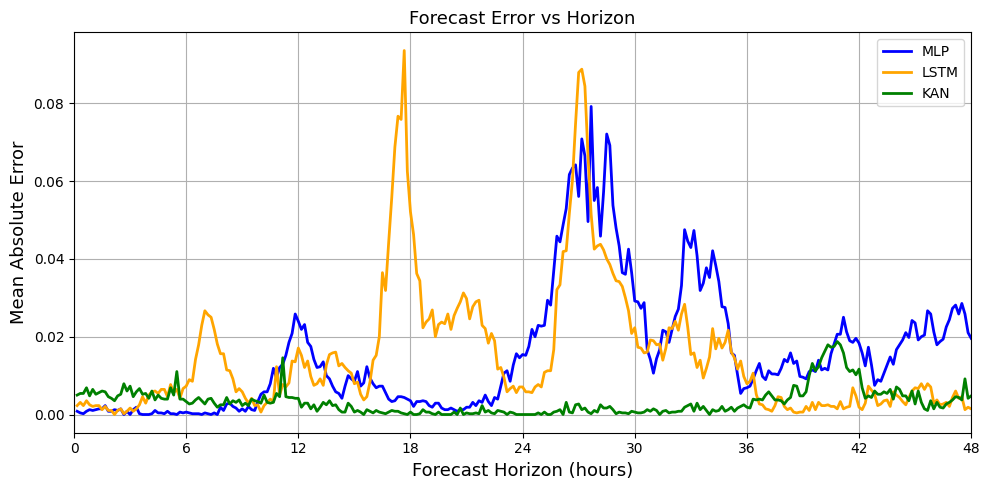

In [11]:
import matplotlib.pyplot as plt
import numpy as np
#create a table to visualize the change in error as the horizon progresses

horizons_in_hours = np.arange(1, HORIZON + 1) / 6

error_list = [table_mlp, table_lstm, table_kan]
labels = ['MLP', 'LSTM', 'KAN']
colors = ['blue', 'orange', 'green']

fig, ax = plt.subplots(figsize=(10, 5))

for errors, label, color in zip(error_list, labels, colors):
    ax.plot(
        horizons_in_hours,
        errors['MAE'],
        label=label,
        color=color,
        linewidth=2
    )

ax.set_xticks(np.arange(0, 49, 6))
ax.set_xlim(left=0, right=48)

ax.set_xlabel('Forecast Horizon (hours)', fontsize=13)
ax.set_ylabel('Mean Absolute Error', fontsize=13)
ax.set_title('Forecast Error vs Horizon', fontsize=13)

ax.grid(True)
ax.legend(loc='upper right')  

plt.tight_layout()

plt.savefig('../report/figures/publish/Error_vs_horizon.pdf')

plt.show()